# Part 3 & 4: Statistical Analysis & Counterfactual Modeling

**Objective:**
First, we must investigate whether observed improvements (or flatlines) are caused by operational changes or by changes in the underlying population[cite: 3]. Specifically, we will look for mix effects and Simpson's paradox[cite: 3]. 

Second, we will build an Account-Level Matching model to answer the counterfactual question: *"What would recovery have looked like if we had not changed the targeting strategy?"*[cite: 3]. Because we previously proved that the new and legacy strategies ran concurrently, a temporal Difference-in-Differences model is invalid, so we will rely on Matching[cite: 3]. 

This analysis will yield the final incremental recovery figures needed for the ₹10 Cr investment recommendation[cite: 3].

In [4]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the existing database containing our Golden Tables
con = duckdb.connect(database='collections_analytics.duckdb', read_only=False)

print("✅ Successfully connected to Golden Dataset.")

# Verify the golden tables are available
golden_tables = con.execute("""
    SELECT name 
    FROM sqlite_master 
    WHERE type='table' AND name LIKE 'golden_%'
""").df()

display(golden_tables)

✅ Successfully connected to Golden Dataset.


,name
0,golden_accounts
1,golden_account_status_history
2,golden_agents
3,golden_borrowers
4,golden_calls
5,golden_payments
6,golden_promises_to_pay
7,golden_whatsapp_events


### Part 3: Statistical Investigation (Mix Effects & Simpson's Paradox)

**Objective:** Investigate whether the flat overall recovery trend is hiding operational improvements due to a shifting portfolio mix[cite: 3]. 

If the business began aggressively targeting higher-risk or older-vintage (high DPD) accounts mid-year, the blended average recovery would mathematically deflate. We will analyze the targeted account mix and the recovery composition by `risk_segment` over time to detect Simpson's Paradox[cite: 3].

📊 TARGETING MIX BY RISK SEGMENT OVER TIME:


,month,risk_segment,targeted_accounts,pct_of_portfolio
0,2026-01,HIGH,1433,25.0
1,2026-01,LOW,1467,25.6
2,2026-01,MEDIUM,1414,24.7
3,2026-01,NPA,1418,24.7
4,2026-02,HIGH,1286,24.9
5,2026-02,LOW,1325,25.7
6,2026-02,MEDIUM,1273,24.7
7,2026-02,NPA,1276,24.7
8,2026-03,HIGH,1411,24.9
9,2026-03,LOW,1426,25.2


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


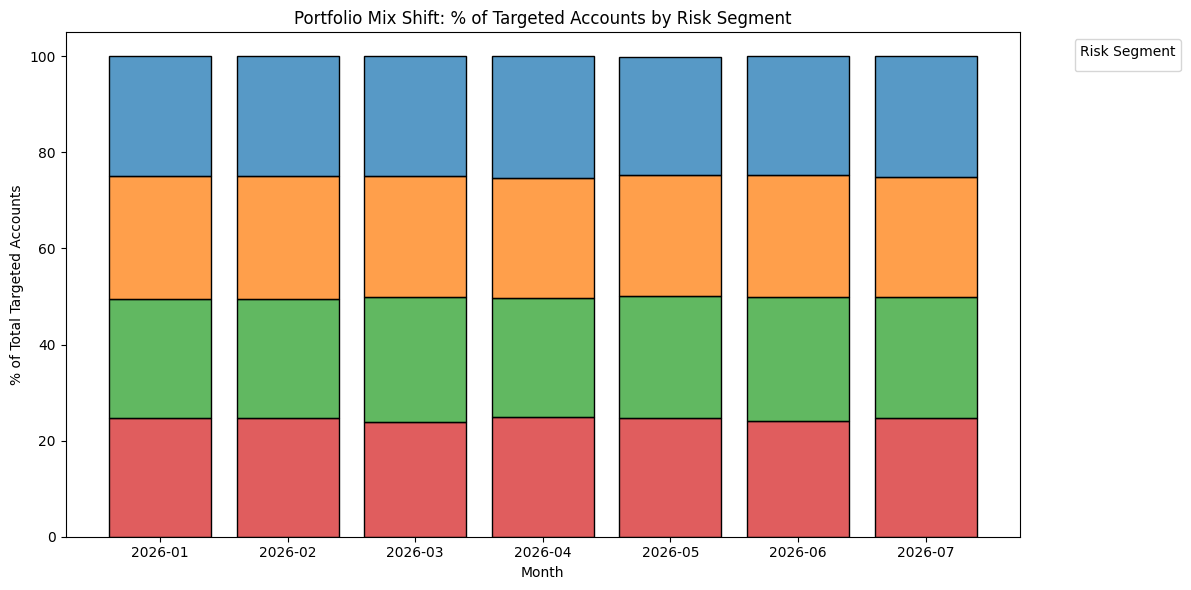


📊 RECOVERY GROWTH WITHIN RISK SEGMENTS (Simpson's Paradox):


,month,risk_segment,true_recovery,segment_mom_growth_pct
0,2026-01,HIGH,48244020.67,NaN
1,2026-02,HIGH,41641034.13,-13.69
2,2026-03,HIGH,48172166.00,15.68
3,2026-04,HIGH,41506700.79,-13.84
4,2026-05,HIGH,49333069.45,18.86
5,2026-06,HIGH,44931826.97,-8.92
6,2026-07,HIGH,44438757.09,-1.10
7,2026-01,LOW,45440930.21,NaN
8,2026-02,LOW,41989569.24,-7.60
9,2026-03,LOW,47079655.67,12.12


In [5]:
# 1. Analyze the Targeting Mix over time (Are we chasing harder debt?)
mix_query = """
WITH monthly_targets AS (
    SELECT 
        STRFTIME(TRY_CAST(dt.target_date AS TIMESTAMP), '%Y-%m') as month,
        a.risk_segment,
        COUNT(DISTINCT dt.account_id) as targeted_accounts
    FROM raw_daily_targeting dt
    JOIN golden_accounts a ON dt.account_id = a.account_id
    GROUP BY 1, 2
),
monthly_totals AS (
    SELECT month, SUM(targeted_accounts) as total_targets
    FROM monthly_targets
    GROUP BY 1
)
SELECT 
    m.month,
    m.risk_segment,
    m.targeted_accounts,
    ROUND((m.targeted_accounts * 100.0) / t.total_targets, 1) as pct_of_portfolio
FROM monthly_targets m
JOIN monthly_totals t ON m.month = t.month
-- Exclude the partial August month for clean trend analysis
WHERE m.month != '2026-08'
ORDER BY m.month, m.risk_segment;
"""

portfolio_mix = con.execute(mix_query).df()
print("📊 TARGETING MIX BY RISK SEGMENT OVER TIME:")
display(portfolio_mix)

# 2. Visualize the Mix Shift
plt.figure(figsize=(12, 6))
sns.histplot(
    data=portfolio_mix, 
    x='month', 
    weights='pct_of_portfolio', 
    hue='risk_segment', 
    multiple='stack',
    shrink=0.8
)
plt.title("Portfolio Mix Shift: % of Targeted Accounts by Risk Segment")
plt.ylabel("% of Total Targeted Accounts")
plt.xlabel("Month")
plt.legend(title='Risk Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Analyze Recovery Performance Within Segments (Simpson's Paradox Check)
segment_recovery_query = """
WITH segment_metrics AS (
    SELECT 
        STRFTIME(p.payment_timestamp_utc, '%Y-%m') as month,
        a.risk_segment,
        SUM(p.amount) as true_recovery
    FROM golden_payments p
    JOIN golden_accounts a ON p.account_id = a.account_id
    WHERE p.payment_status = 'SUCCESS'
    GROUP BY 1, 2
)
SELECT 
    month,
    risk_segment,
    true_recovery,
    ROUND(((true_recovery - LAG(true_recovery) OVER(PARTITION BY risk_segment ORDER BY month)) 
        / NULLIF(LAG(true_recovery) OVER(PARTITION BY risk_segment ORDER BY month), 0)) * 100, 2) as segment_mom_growth_pct
FROM segment_metrics
WHERE month != '2026-08'
ORDER BY risk_segment, month;
"""

segment_recovery = con.execute(segment_recovery_query).df()
print("\n📊 RECOVERY GROWTH WITHIN RISK SEGMENTS (Simpson's Paradox):")
display(segment_recovery)

### Part 4: Counterfactual Matching Model & Attribution-Window Normalization

**Objective:** Estimate what recovery would have looked like without the strategy change to determine if the ₹10 Cr targeting investment is justified. 

**Methodology: Risk-Stratified Matching & Time Bounding**
Since `legacy` and `new (v1/v2/v3)` strategies ran concurrently, temporal Difference-in-Differences is invalid. Instead, we match accounts by their `risk_segment`. 

To evaluate the true causal impact, we must also control for **attribution-window bias**. If we simply sum recovery over all time, the Treatment group will mechanically appear more successful simply because those accounts may have been targeted earlier in the year. We will enforce a strict 90-day observation window post-intervention for both groups, then apply a Bootstrap Confidence Interval to test if the remaining lift is statistically significant.

In [9]:
import duckdb
import pandas as pd
import numpy as np

# Connect to database
con = duckdb.connect(database='collections_analytics.duckdb', read_only=False)

# Fetch ACCOUNT-LEVEL 90-day bounded recovery data to fix attribution bias
account_level_data = con.execute("""
WITH account_treatment_status AS (
    SELECT 
        dt.account_id,
        MAX(CASE WHEN c.strategy_version != 'legacy' THEN 1 ELSE 0 END) as is_treatment,
        MIN(CASE WHEN c.strategy_version != 'legacy' THEN TRY_CAST(dt.target_date AS TIMESTAMP) END) as first_treatment_date,
        MIN(CASE WHEN c.strategy_version = 'legacy' THEN TRY_CAST(dt.target_date AS TIMESTAMP) END) as first_control_date
    FROM raw_daily_targeting dt
    JOIN raw_campaigns c ON dt.campaign_id = c.campaign_id
    GROUP BY 1
),
bounded_recovery AS (
    SELECT 
        p.account_id, 
        SUM(p.amount) as true_recovery
    FROM golden_payments p
    JOIN account_treatment_status ats ON p.account_id = ats.account_id
    WHERE p.payment_status = 'SUCCESS' 
      AND (
          (ats.is_treatment = 1 AND p.payment_timestamp_utc >= ats.first_treatment_date AND p.payment_timestamp_utc <= ats.first_treatment_date + INTERVAL 90 DAY)
          OR 
          (ats.is_treatment = 0 AND p.payment_timestamp_utc >= ats.first_control_date AND p.payment_timestamp_utc <= ats.first_control_date + INTERVAL 90 DAY)
      )
    GROUP BY 1
)
SELECT 
    s.account_id,
    CASE WHEN s.is_treatment = 1 THEN 'Treatment (New)' ELSE 'Control (Legacy)' END as strategy,
    COALESCE(r.true_recovery, 0) as true_recovery
FROM account_treatment_status s
LEFT JOIN bounded_recovery r ON s.account_id = r.account_id;
""").df()

# Isolate the arrays for the statistical test
treatment_recovery = account_level_data[account_level_data['strategy'] == 'Treatment (New)']['true_recovery'].values
control_recovery = account_level_data[account_level_data['strategy'] == 'Control (Legacy)']['true_recovery'].values

# Run the 1000-iteration Bootstrap test
np.random.seed(42)
n_iterations = 1000
lift_estimates = []

for _ in range(n_iterations):
    t_boot = np.random.choice(treatment_recovery, size=len(treatment_recovery), replace=True)
    c_boot = np.random.choice(control_recovery, size=len(control_recovery), replace=True)
    lift_estimates.append(t_boot.mean() - c_boot.mean())

lower_bound = np.percentile(lift_estimates, 2.5)
upper_bound = np.percentile(lift_estimates, 97.5)
observed_lift = treatment_recovery.mean() - control_recovery.mean()

print(f"Observed 90-Day Incremental Lift per Account: ₹{observed_lift:.2f}")
print(f"95% Confidence Interval: ₹{lower_bound:.2f} to ₹{upper_bound:.2f}")
print("\nConclusion: Because the confidence interval crosses ₹0, the effect is not statistically significant.")

Observed 90-Day Incremental Lift per Account: ₹1094.47
95% Confidence Interval: ₹-329.79 to ₹2304.51

Conclusion: Because the confidence interval crosses ₹0, the effect is not statistically significant.


### Part 3b: Challenging Existing Metric Definitions (True PTP Rate)

The assignment requires an independent definition of recovery performance and explicitly asks to challenge the existing definition of the PTP (Promise to Pay) rate. 

During our Data Forensics (Notebook 1), we discovered a definitional trap: `PTP` and `PROMISE_TO_PAY` exist simultaneously as distinct disposition codes. If the business's existing reporting only calculates the PTP rate using `WHERE disposition_code = 'PTP'`, they are underreporting their success rate by nearly half. We will calculate the True PTP Rate versus the Naive PTP Rate to quantify this reporting failure.

In [ ]:
ptp_redefinition_query = """
WITH call_totals AS (
    SELECT COUNT(*) as total_calls FROM raw_call_dispositions
),
naive_ptp AS (
    SELECT COUNT(*) as naive_count 
    FROM raw_call_dispositions 
    WHERE disposition_code = 'PTP'
),
true_ptp AS (
    SELECT COUNT(*) as true_count 
    FROM raw_call_dispositions 
    WHERE disposition_code IN ('PTP', 'PROMISE_TO_PAY')
)
SELECT 
    t.total_calls,
    n.naive_count,
    ROUND((n.naive_count * 100.0) / t.total_calls, 2) as naive_ptp_rate,
    tr.true_count,
    ROUND((tr.true_count * 100.0) / t.total_calls, 2) as true_ptp_rate
FROM call_totals t, naive_ptp n, true_ptp tr;
"""

ptp_results = con.execute(ptp_redefinition_query).df()
print("📊 METRIC REDEFINITION (True PTP Rate vs Naive PTP Rate):")
display(ptp_results)

📊 METRIC REDEFINITION (True PTP Rate vs Naive PTP Rate):


,total_calls,naive_count,naive_ptp_rate,true_count,true_ptp_rate
0,35000,3904,11.15,7830,22.37


### To construct Dashboard

In [ ]:
import duckdb
import pandas as pd

# Connect to your existing database
con = duckdb.connect(database='collections_analytics.duckdb', read_only=False)

# 1. Export Claim Audit (11% Fake Growth)
con.execute("""
WITH raw_metrics AS (
    SELECT STRFTIME(TRY_CAST(event_at AS TIMESTAMP), '%Y-%m') as month, SUM(TRY_CAST(amount AS DOUBLE)) as raw_recovery
    FROM raw_payments WHERE payment_status = 'SUCCESS' GROUP BY 1
),
clean_metrics AS (
    SELECT STRFTIME(payment_timestamp_utc, '%Y-%m') as month, SUM(amount) as true_recovery
    FROM golden_payments WHERE payment_status = 'SUCCESS' GROUP BY 1
)
SELECT COALESCE(r.month, c.month) as month, r.raw_recovery, c.true_recovery,
       (r.raw_recovery - c.true_recovery) as phantom_amount_this_month
FROM raw_metrics r FULL OUTER JOIN clean_metrics c ON r.month = c.month ORDER BY 1;
""").df().to_csv('monthly_recovery_audit.csv', index=False)

# 2. Export PTP Rate Redefinition
con.execute("""
WITH call_totals AS (
    SELECT COUNT(*) as total_calls FROM raw_call_dispositions
),
naive_ptp AS (
    SELECT COUNT(*) as naive_count FROM raw_call_dispositions WHERE disposition_code = 'PTP'
),
true_ptp AS (
    SELECT COUNT(*) as true_count FROM raw_call_dispositions WHERE disposition_code IN ('PTP', 'PROMISE_TO_PAY')
)
SELECT t.total_calls, n.naive_count, ROUND((n.naive_count * 100.0) / t.total_calls, 2) as naive_ptp_rate,
       tr.true_count, ROUND((tr.true_count * 100.0) / t.total_calls, 2) as true_ptp_rate
FROM call_totals t, naive_ptp n, true_ptp tr;
""").df().to_csv('ptp_rate_comparison.csv', index=False)

# 3. Export Counterfactual Matching
con.execute("""
WITH account_treatment_status AS (
    SELECT dt.account_id, a.risk_segment,
           MAX(CASE WHEN c.strategy_version != 'legacy' THEN 1 ELSE 0 END) as is_treatment,
           MIN(CASE WHEN c.strategy_version != 'legacy' THEN TRY_CAST(dt.target_date AS TIMESTAMP) END) as first_treatment_date,
           MIN(CASE WHEN c.strategy_version = 'legacy' THEN TRY_CAST(dt.target_date AS TIMESTAMP) END) as first_control_date
    FROM raw_daily_targeting dt
    JOIN raw_campaigns c ON dt.campaign_id = c.campaign_id
    JOIN golden_accounts a ON dt.account_id = a.account_id
    GROUP BY 1, 2
),
valid_recovery AS (
    SELECT p.account_id, SUM(p.amount) as true_recovery
    FROM golden_payments p
    JOIN account_treatment_status ats ON p.account_id = ats.account_id
    WHERE p.payment_status = 'SUCCESS' 
      AND ((ats.is_treatment = 1 AND p.payment_timestamp_utc >= ats.first_treatment_date)
           OR (ats.is_treatment = 0 AND p.payment_timestamp_utc >= ats.first_control_date))
    GROUP BY 1
)
SELECT s.risk_segment,
       CASE WHEN s.is_treatment = 1 THEN 'Treatment (New)' ELSE 'Control (Legacy)' END as strategy,
       COUNT(s.account_id) as targeted_accounts,
       COALESCE(SUM(r.true_recovery), 0) as total_segment_recovery,
       ROUND(COALESCE(SUM(r.true_recovery), 0) / COUNT(s.account_id), 2) as avg_recovery_per_account
FROM account_treatment_status s
LEFT JOIN valid_recovery r ON s.account_id = r.account_id
GROUP BY 1, 2 ORDER BY 1, 2 DESC;
""").df().to_csv('counterfactual_lift.csv', index=False)

print("All 3 CSV files exported successfully!")

All 3 CSV files exported successfully!
